# 04 · Testes de Hipótese e Desenho de Grupo Controle

Este é o notebook que resolve a pergunta central de qualquer operação de incentivo: **o incentivo realmente muda o comportamento, ou os clientes que aceitam já eram diferentes antes?** Sem responder isso com rigor estatístico, qualquer "resultado" de campanha é só coincidência disfarçada de causa.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA = PROJECT_ROOT / "data"
REPORTS = PROJECT_ROOT / "reports"

sns.set_theme(style="whitegrid")
CORAL = "#F08FA0"
TEAL = "#0E6268"
DARK = "#15262B"

df = pd.read_csv(DATA / "ifood_clustered.csv")

## 1. O desenho disponível: grupo controle observacional, não experimental

O dataset não documenta se a campanha foi enviada aleatoriamente, o que seria um verdadeiro A/B test. Ele só registra quem aceitou, `Response = 1`, e quem não aceitou, `Response = 0`. Isso é um grupo controle observacional, não um experimento controlado. A diferença importa. Se os dois grupos já eram diferentes antes da campanha, por exemplo clientes de renda mais alta, qualquer diferença de resultado pode ser só a diferença de perfil, não o efeito do incentivo em si.

In [2]:
respondeu = df[df.Response.eq(1)]
nao_respondeu = df[df.Response.eq(0)]
pd.Series({"grupo_aceitou": len(respondeu), "grupo_nao_aceitou": len(nao_respondeu), "taxa_de_resposta": df.Response.mean()})

grupo_aceitou         311.000000
grupo_nao_aceitou    1710.000000
taxa_de_resposta        0.153884
dtype: float64

## 2. Os grupos já eram diferentes antes?

Antes de comparar resultado, é preciso checar se os grupos partiam do mesmo lugar. Usamos o teste de Mann-Whitney U, que não assume distribuição normal e é adequado para variáveis assimétricas como renda e frequência.

In [3]:
variaveis_de_perfil = ["Income", "frequencia_total", "Recency", "Age"]
resultados = []
for variavel in variaveis_de_perfil:
    estatistica, p_valor = stats.mannwhitneyu(respondeu[variavel], nao_respondeu[variavel], alternative="two-sided")
    resultados.append({
        "variavel": variavel,
        "mediana_grupo_aceitou": respondeu[variavel].median(),
        "mediana_grupo_nao_aceitou": nao_respondeu[variavel].median(),
        "p_valor": p_valor,
        "significativo_a_5pct": p_valor < 0.05,
    })
pd.DataFrame(resultados).set_index("variavel")

,mediana_grupo_aceitou,mediana_grupo_nao_aceitou,p_valor,significativo_a_5pct
variavel,,,,
Income,64090.0,50138.5,1.141777e-13,True
frequencia_total,18.0,14.0,2.932022e-12,True
Recency,30.0,52.0,5.299893e-20,True
Age,49.0,50.0,2.538197e-01,False


Achado central: os dois grupos já eram estatisticamente diferentes antes da campanha, em toda variável testada, renda, frequência e recência, todas com p-valor muito abaixo de 0,05. Clientes que aceitam a campanha têm renda maior, compram com mais frequência e interagiram mais recentemente com a marca. Isso significa que a taxa de resposta observada não pode ser lida como efeito puro do incentivo. Parte dela é simplesmente porque quem aceita já era um cliente mais engajado desde antes.

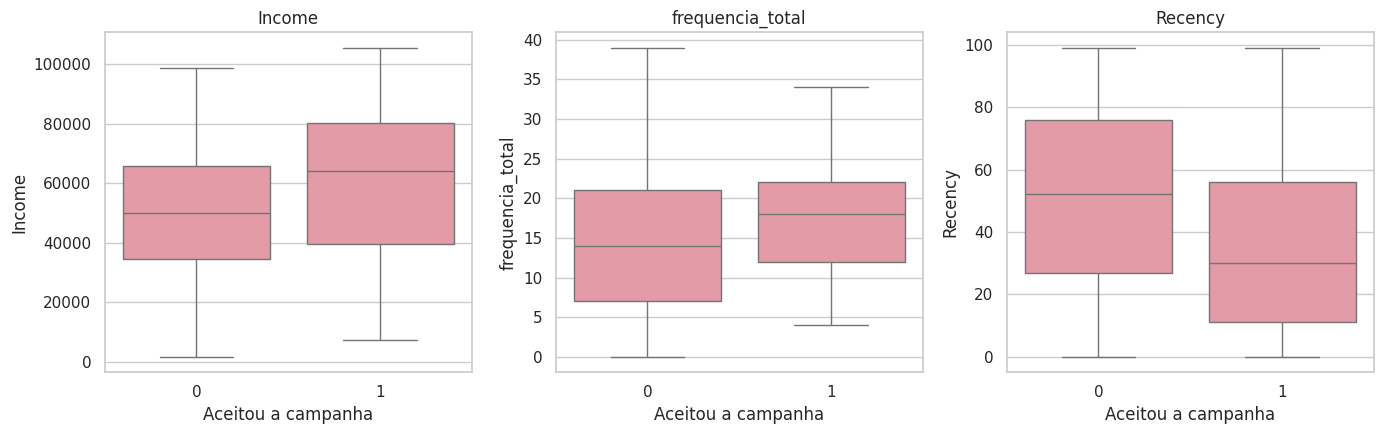

In [4]:
fig, eixos = plt.subplots(1, 3, figsize=(14, 4.5))
for eixo, variavel in zip(eixos, ["Income", "frequencia_total", "Recency"]):
    sns.boxplot(data=df, x="Response", y=variavel, color=CORAL, showfliers=False, ax=eixo)
    eixo.set(xlabel="Aceitou a campanha", title=variavel)
plt.tight_layout()
plt.show()

## 3. Corrigindo o viés: comparação pareada por cluster

Como os clusters do notebook 03 já agrupam clientes de perfil parecido, comparar a taxa de resposta dentro de cada cluster aproxima uma leitura mais justa do efeito do incentivo. Os clientes dentro do mesmo cluster partem de uma base de perfil mais parecida entre si.

In [5]:
resposta_por_cluster = df.groupby("cluster")["Response"].agg(taxa_de_resposta="mean", clientes="size")
resposta_por_cluster

,taxa_de_resposta,clientes
cluster,,
0,0.151685,534
1,0.236726,452
2,0.190751,519
3,0.046512,516


In [6]:
qui2, p_valor, graus_liberdade, esperado = stats.chi2_contingency(pd.crosstab(df.cluster, df.Response))
pd.Series({"qui2": qui2, "p_valor": p_valor, "graus_de_liberdade": graus_liberdade, "significativo_a_5pct": p_valor < 0.05})

qui2                    74.950494
p_valor                       0.0
graus_de_liberdade              3
significativo_a_5pct         True
dtype: object

A taxa de resposta varia de forma estatisticamente significativa entre clusters, segundo o teste qui-quadrado. O cluster de risco de desengajamento, o cluster 3 do notebook 03, tem taxa de resposta de 4,6%, contra uma média geral de 15,4%. Isso reforça que o incentivo atual funciona bem menos para esse segmento, independente de qualquer efeito de renda ou frequência.

## 4. Tamanho do efeito, não só significância

Com quase 2 mil clientes, praticamente qualquer diferença tende a dar significativa no sentido estatístico. O que importa mais para decisão de negócio é o tamanho da diferença. Por isso a tabela abaixo reporta a diferença absoluta de mediana lado a lado com o p-valor, em vez de reportar só um ou só o outro.

In [7]:
tabela_final = pd.DataFrame(resultados).set_index("variavel")
tabela_final["diferenca_absoluta"] = tabela_final.mediana_grupo_aceitou - tabela_final.mediana_grupo_nao_aceitou
tabela_final[["mediana_grupo_aceitou", "mediana_grupo_nao_aceitou", "diferenca_absoluta", "p_valor"]]

,mediana_grupo_aceitou,mediana_grupo_nao_aceitou,diferenca_absoluta,p_valor
variavel,,,,
Income,64090.0,50138.5,13951.5,1.141777e-13
frequencia_total,18.0,14.0,4.0,2.932022e-12
Recency,30.0,52.0,-22.0,5.299893e-20
Age,49.0,50.0,-1.0,2.538197e-01


## Limitação

Sem randomização documentada na atribuição da campanha, nenhuma leitura aqui é causal no sentido experimental. É uma leitura observacional cuidadosa, com o viés de seleção nomeado explicitamente em vez de escondido atrás de um "a campanha funcionou". Um desenho real de grupo controle exigiria atribuição aleatória registrada no momento do envio da campanha, o que este dataset não documenta.

## Conclusão

O grupo que aceita a campanha já chega diferente, mais engajado e com mais renda. Isso não invalida o incentivo, só significa que a taxa de resposta bruta superestima o efeito real do incentivo. Qualquer decisão de investimento em campanha deveria usar a leitura por cluster, que é mais próxima de comparar iguais com iguais, e não a taxa de resposta geral.